In [22]:
import pandas as pd
from emi_receiver import *

In [23]:
import numpy as np
import matplotlib.pyplot as plt

50000 50000


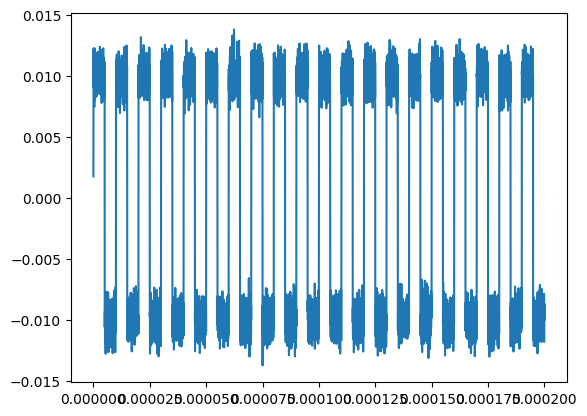

In [24]:
fs= 50e6
t = np.arange(0, 1e-3, 1/fs)
signal = np.sin(t*2*np.pi*100_000)
mask= np.abs(signal) >0.01
signal[mask]=0.01*np.sign(signal[mask]) 
np.random.seed(0)
noise = np.random.normal(0, 0.001, signal.shape)
signal = signal + noise
Nplot = 10_000
print(len(t), len(signal))
plt.plot(t[:Nplot], signal[:Nplot])
plt.show()

In [25]:
freqs, peak, avg, qp = receiver(signal, fs, rbw=9000, step=2500, band='B')

--------------------------------------------------
EMI Receiver Configuration:
  RBW           : 9000 Hz
  Step Size     : 2500.00 Hz (Target: 2500 Hz)
  Window Size   : 12493 samples
  FFT Size      : 20000 samples (Zero-Padding: True)
  Detector Time : 0.025 ms
--------------------------------------------------


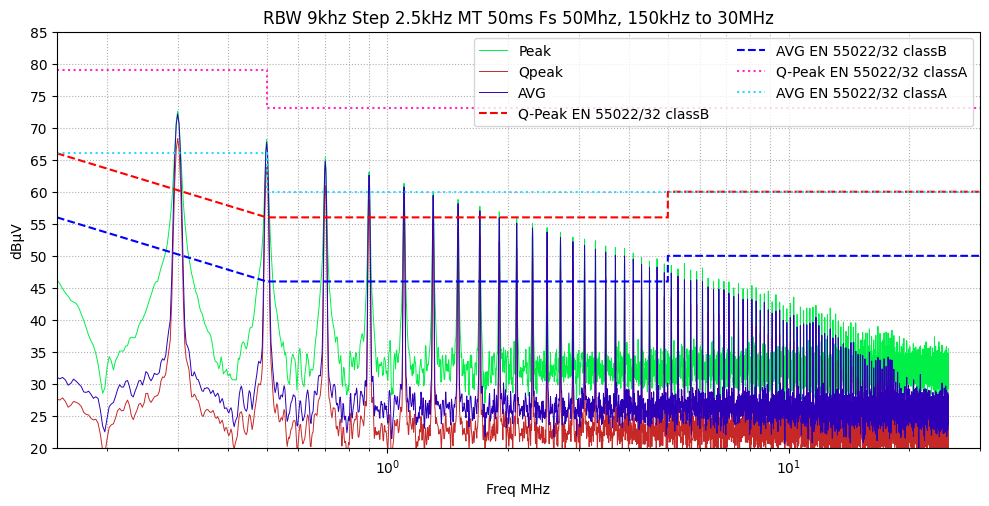

In [26]:
# 3. Plot the results

plt.figure(figsize=(10,5))
plt.semilogx(freqs*1e-6, peak, label='Peak', color='#00F047', linewidth=0.7)
plt.semilogx(freqs*1e-6, qp, label='Qpeak', color='#C62828', linewidth=0.7) 
plt.semilogx(freqs*1e-6, avg, label='AVG', color='#2D00B8', linewidth=0.7)


# Class A: Limits for industrial/commercial environments → less strict (higher allowed emissions).
# Class B: Limits for residential environments → more strict (lower allowed emissions).
freqs0 = np.array([150e3, 500e3, 5e6, 5e6,30e6])
qp_limits = np.array([66, 56, 56, 60, 60])   # dBµV
avg_limits = np.array([56, 46, 46, 50,50])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classB', c="r",linestyle="--")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classB', c= "b",linestyle="--")


# CISPR 22 / EN 55032 - CLASS A (Industrial) - Mains Port
# Note: Class A has a step at 500 kHz, not 5 MHz.
freqs0 = np.array([150e3, 500e3, 500e3, 30e6])
qp_limits = np.array([79.0, 79.0, 73.0, 73.0])   # dBµV
avg_limits = np.array([66.0, 66.0, 60.0, 60.0])  # dBµV
plt.semilogx(freqs0*1e-6, qp_limits ,   label='Q-Peak EN 55022/32 classA', c="#FF29C2",linestyle="dotted")
plt.semilogx(freqs0*1e-6,avg_limits  ,   label='AVG EN 55022/32 classA', c= "#29DBFF",linestyle="dotted")

plt.ylim(20, 85)
plt.yticks(np.arange(20, 85+1, 5))
plt.grid(True)
plt.grid(True, which='both', ls=':')
plt.xlabel('Freq MHz')
plt.xlim([0.15, 30])
plt.ylabel('dBµV')
plt.legend(ncol=2)
plt.tight_layout()
plt.title("RBW 9khz Step 2.5kHz MT 50ms Fs 50Mhz, 150kHz to 30MHz")
#plt.savefig("ExampleOfUse.png")
plt.show()